In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import os

In [10]:
def load_dataset(file_path, parse_dates=None):
    return pd.read_csv(file_path, parse_dates=parse_dates)

In [11]:
Clean_Adspend = load_dataset(
    "../data/cleaned_data/cleaned_Adspend_Table.csv",
    parse_dates=["date"]
)

Clean_Weblogs = load_dataset(
    "../data/cleaned_data/cleaned_User_Weblogs.csv",
    parse_dates=["timestamp"]
)

Clean_Customer = load_dataset(
    "../data/cleaned_data/cleaned_Customer_Table.csv",
    parse_dates=[
        "first_touch_date",
        "last_touch_date",
        "conversion_date"
    ]
)

Clean_Conversion = load_dataset(
    "../data/cleaned_data/cleaned_Conversion_Table.csv",
    parse_dates=["conversion_date"]
)

In [12]:
def explore_dataset(df, name):
   
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)

    # Shape
    print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")

    # Column names
    print("\nColumns:")
    print(df.columns.tolist())

    # Data types and missing values
    print("\nDataset Information:")
    print(df.info())

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Summary statistics
    print("\nSummary Statistics:")
    print(df.describe(include='all').T)

    # First five rows
    print("\nFirst Five Rows:")
    display(df.head())

In [13]:
explore_dataset(Clean_Adspend, "AdSpend")
explore_dataset(Clean_Weblogs, "WebLogs")
explore_dataset(Clean_Customer, "CUSTOMERS")
explore_dataset(Clean_Conversion, "Conversion")

Dataset: AdSpend

Shape: 724 rows × 11 columns

Columns:
['date', 'channel', 'campaign', 'spend', 'date_quarter', 'date_month_name', 'date_day_name', 'date_day_of_week', 'date_week', 'date_hour', 'date_is_weekend']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              724 non-null    datetime64[ns, UTC]
 1   channel           724 non-null    object             
 2   campaign          724 non-null    object             
 3   spend             724 non-null    float64            
 4   date_quarter      724 non-null    int64              
 5   date_month_name   724 non-null    object             
 6   date_day_name     724 non-null    object             
 7   date_day_of_week  724 non-null    int64              
 8   date_week         724 non-null    int64              
 9   date

,date,channel,campaign,spend,date_quarter,date_month_name,date_day_name,date_day_of_week,date_week,date_hour,date_is_weekend
0,2025-01-01 00:00:00+00:00,Google Ads,Competitor Search,2185.43,1,January,Wednesday,2,1,0,False
1,2025-01-01 00:00:00+00:00,Facebook Ads,Winter Sale,4778.21,1,January,Wednesday,2,1,0,False
2,2025-01-01 00:00:00+00:00,Tiktok Ads,Influencer Push,3793.97,1,January,Wednesday,2,1,0,False
3,2025-01-01 00:00:00+00:00,Organic,Organic Landing,0.00,1,January,Wednesday,2,1,0,False
4,2025-01-02 00:00:00+00:00,Google Ads,Brand Search,3193.96,1,January,Thursday,3,1,0,False


Dataset: WebLogs

Shape: 45815 rows × 17 columns

Columns:
['user_id', 'timestamp', 'region', 'device', 'channel', 'campaign', 'event_type', 'utm_source', 'utm_medium', 'utm_campaign', 'quarter', 'month_name', 'day_name', 'day_of_week', 'week', 'hour', 'is_weekend']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45815 entries, 0 to 45814
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   user_id       45815 non-null  object             
 1   timestamp     26683 non-null  datetime64[ns, UTC]
 2   region        45815 non-null  object             
 3   device        45815 non-null  object             
 4   channel       45815 non-null  object             
 5   campaign      45815 non-null  object             
 6   event_type    45815 non-null  object             
 7   utm_source    45815 non-null  object             
 8   utm_medium    45815 non-null  object           

,user_id,timestamp,region,device,channel,campaign,event_type,utm_source,utm_medium,utm_campaign,quarter,month_name,day_name,day_of_week,week,hour,is_weekend
0,U00001,2025-05-14 18:56:35+00:00,North America,Desktop,Organic,Organic Landing,Visit,organic_search,organic,Organic Landing,2.0,May,Wednesday,2.0,20.0,18.0,False
1,U00001,NaT,North America,Desktop,Tiktok Ads,Influencer Push,Product View,tiktok_ads,social,Influencer Push,NaN,NaN,NaN,NaN,NaN,NaN,False
2,U00002,NaT,North America,Desktop,Tiktok Ads,UGC Campaign,Product View,tiktok_ads,organic,UGC Campaign,NaN,NaN,NaN,NaN,NaN,NaN,False
3,U00002,2025-04-09 10:58:50+00:00,North America,Desktop,Facebook Ads,Retargeting,Visit,facebook_ads,organic,Retargeting,2.0,April,Wednesday,2.0,15.0,10.0,False
4,U00003,2025-01-23 07:05:32+00:00,Asia Pacific,Tablet,Organic,Organic Landing,Product View,organic_search,organic,Organic Landing,1.0,January,Thursday,3.0,4.0,7.0,False


Dataset: CUSTOMERS

Shape: 10000 rows × 33 columns

Columns:
['customer_key', 'user_id', 'region', 'primary_device', 'first_touch_date', 'last_touch_date', 'total_touchpoints', 'conversion_flag', 'conversion_date', 'revenue', 'channel', 'campaign', 'first_touch_date_quarter', 'first_touch_date_month_name', 'first_touch_date_day_name', 'first_touch_date_day_of_week', 'first_touch_date_week', 'first_touch_date_hour', 'first_touch_date_is_weekend', 'last_touch_date_quarter', 'last_touch_date_month_name', 'last_touch_date_day_name', 'last_touch_date_day_of_week', 'last_touch_date_week', 'last_touch_date_hour', 'last_touch_date_is_weekend', 'conversion_date_quarter', 'conversion_date_month_name', 'conversion_date_day_name', 'conversion_date_day_of_week', 'conversion_date_week', 'conversion_date_hour', 'conversion_date_is_weekend']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                     

,customer_key,user_id,region,primary_device,first_touch_date,last_touch_date,total_touchpoints,conversion_flag,conversion_date,revenue,...,last_touch_date_week,last_touch_date_hour,last_touch_date_is_weekend,conversion_date_quarter,conversion_date_month_name,conversion_date_day_name,conversion_date_day_of_week,conversion_date_week,conversion_date_hour,conversion_date_is_weekend
0,1,U00001,North America,Desktop,2025-05-14 18:56:35+00:00,2025-05-16 12:56:00+00:00,2,True,2025-05-15 09:56:35+00:00,427.99,...,20,12,False,2.0,May,Thursday,3.0,20.0,9.0,False
1,2,U00002,North America,Desktop,2025-04-04 15:58:00+00:00,2025-04-09 10:58:50+00:00,2,False,NaT,0.00,...,15,10,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,3,U00003,Asia Pacific,Tablet,2025-01-23 07:05:32+00:00,2025-02-02 02:05:32+00:00,4,False,NaT,0.00,...,5,2,True,NaN,NaN,NaN,NaN,NaN,NaN,False
3,4,U00004,Asia Pacific,Mobile,2025-02-10 11:39:23+00:00,2025-02-12 19:39:00+00:00,2,False,NaT,0.00,...,7,19,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,5,U00005,Asia Pacific,Tablet,2025-02-21 15:28:06+00:00,2025-02-21 22:28:00+00:00,2,True,2025-02-24 19:28:00+00:00,470.38,...,8,22,False,1.0,February,Monday,0.0,9.0,19.0,False


Dataset: Conversion

Shape: 1564 rows × 10 columns

Columns:
['user_id', 'conversion_date', 'revenue', 'conversion_date_quarter', 'conversion_date_month_name', 'conversion_date_day_name', 'conversion_date_day_of_week', 'conversion_date_week', 'conversion_date_hour', 'conversion_date_is_weekend']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564 entries, 0 to 1563
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   user_id                      1564 non-null   object             
 1   conversion_date              1564 non-null   datetime64[ns, UTC]
 2   revenue                      1564 non-null   float64            
 3   conversion_date_quarter      1564 non-null   int64              
 4   conversion_date_month_name   1564 non-null   object             
 5   conversion_date_day_name     1564 non-null   object             
 6   conversio

,user_id,conversion_date,revenue,conversion_date_quarter,conversion_date_month_name,conversion_date_day_name,conversion_date_day_of_week,conversion_date_week,conversion_date_hour,conversion_date_is_weekend
0,U00001,2025-05-15 09:56:35+00:00,427.99,2,May,Thursday,3,20,9,False
1,U00005,2025-02-24 19:28:00+00:00,470.38,1,February,Monday,0,9,19,False
2,U00006,2025-04-26 04:32:00+00:00,853.58,2,April,Saturday,5,17,4,True
3,U00008,2025-06-23 04:00:04+00:00,790.46,2,June,Monday,0,26,4,False
4,U00009,2025-06-13 17:55:21+00:00,385.54,2,June,Friday,4,24,17,False


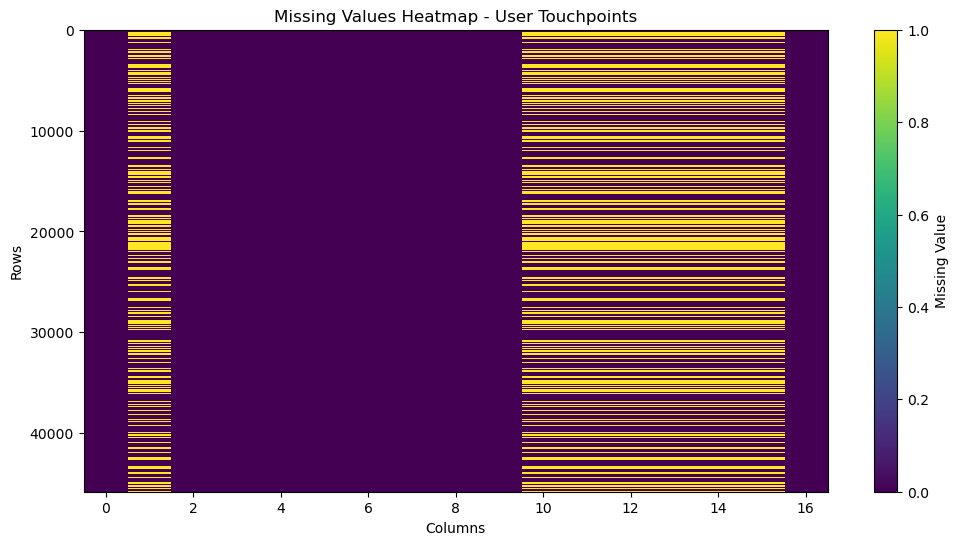

In [15]:
plt.figure(figsize=(12,6))

plt.imshow(Clean_Weblogs.isnull(), aspect='auto', interpolation='nearest')

plt.title("Missing Values Heatmap - User Touchpoints")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.colorbar(label="Missing Value")

plt.show()

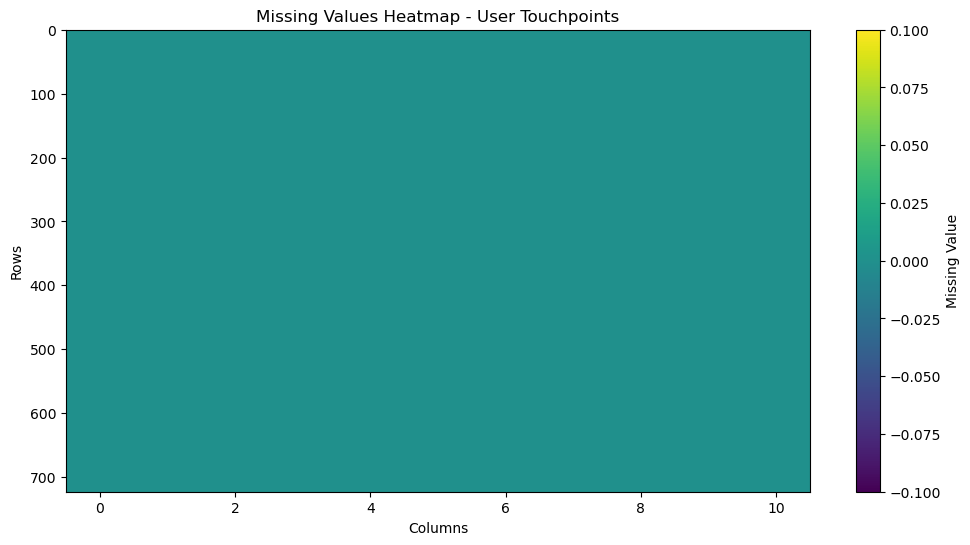

In [16]:
plt.figure(figsize=(12,6))

plt.imshow(Clean_Adspend.isnull(), aspect='auto', interpolation='nearest')

plt.title("Missing Values Heatmap - User Touchpoints")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.colorbar(label="Missing Value")

plt.show()

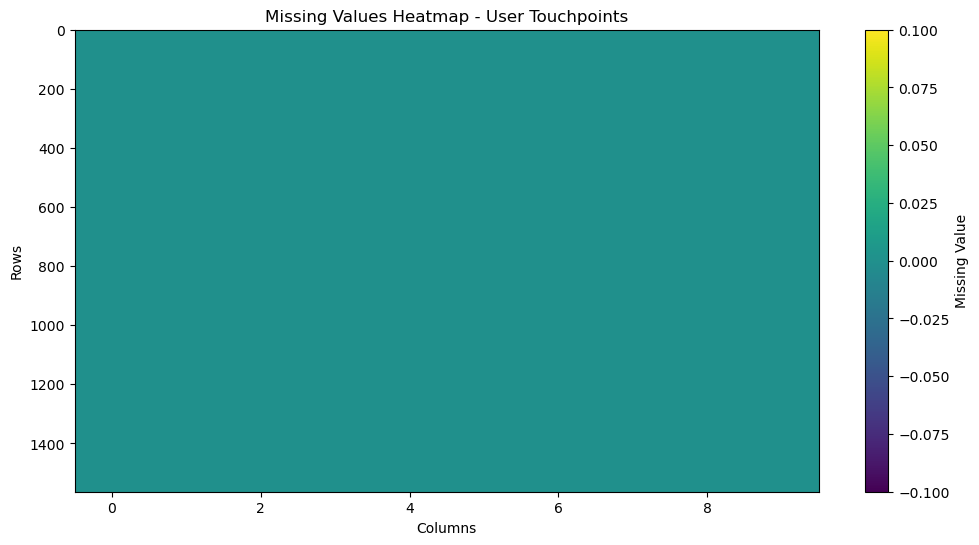

In [17]:
plt.figure(figsize=(12,6))

plt.imshow(Clean_Conversion.isnull(), aspect='auto', interpolation='nearest')

plt.title("Missing Values Heatmap - User Touchpoints")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.colorbar(label="Missing Value")

plt.show()

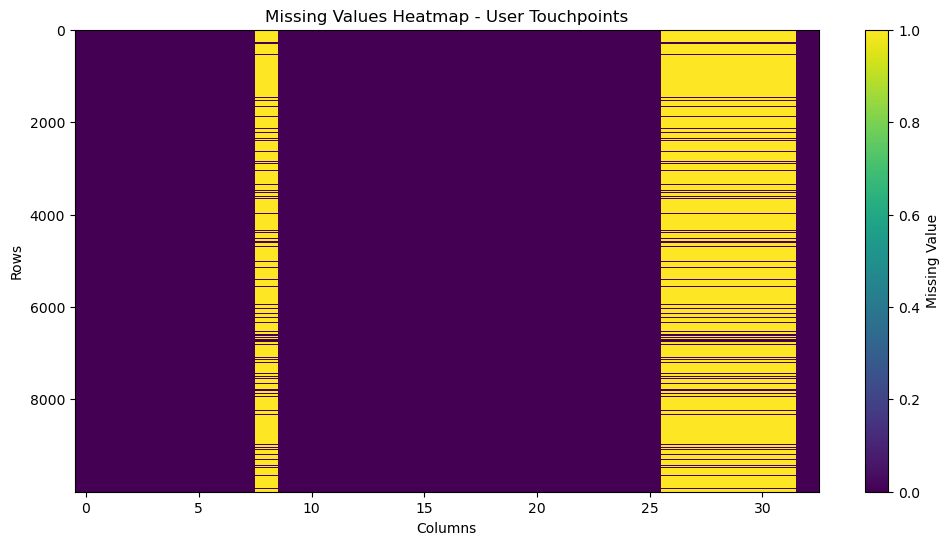

In [18]:
plt.figure(figsize=(12,6))

plt.imshow(Clean_Customer.isnull(), aspect='auto', interpolation='nearest')

plt.title("Missing Values Heatmap - User Touchpoints")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.colorbar(label="Missing Value")

plt.show()

Traffic Source Analysis

In [ ]:
channel_counts = Clean_Weblogs['channel'].value_counts()
print(channel_counts)

channel
Organic         11482
Facebook Ads    11466
Google Ads      11457
Tiktok Ads      11410
Name: count, dtype: int64


In [20]:
channel_counts = Clean_Adspend['channel'].value_counts()
print(channel_counts)

channel
Google Ads      181
Facebook Ads    181
Tiktok Ads      181
Organic         181
Name: count, dtype: int64


In [22]:
channel_counts = Clean_Customer['channel'].value_counts()
print(channel_counts)

channel
Tiktok Ads      2536
Organic         2529
Facebook Ads    2521
Google Ads      2414
Name: count, dtype: int64


Channel Distribution Chart

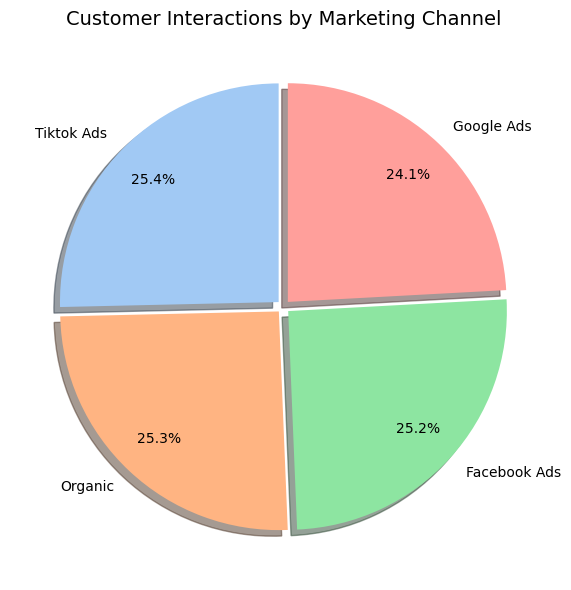

In [28]:
plt.figure(figsize=(8, 6))

colors = sns.color_palette("pastel")

channel_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    colors=colors,
    explode=[0.03] * len(channel_counts),
    pctdistance=0.8
)

plt.title("Customer Interactions by Marketing Channel", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()

Top Channels

In [29]:
print("Top Performing Channels")

print(channel_counts.head())

Top Performing Channels
channel
Tiktok Ads      2536
Organic         2529
Facebook Ads    2521
Google Ads      2414
Name: count, dtype: int64


Customer Journey Analysis

In [35]:
#Number of Touchpoints per Customer
touchpoints_per_customer = Clean_Weblogs.groupby('user_id').size()
touchpoints_per_customer.head()

user_id
U00001    2
U00002    2
U00003    4
U00004    2
U00005    2
dtype: int64

In [36]:
#Summary Statistics
touchpoints_per_customer.describe()

count    10000.000000
mean         4.581500
std          1.760246
min          2.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
dtype: float64

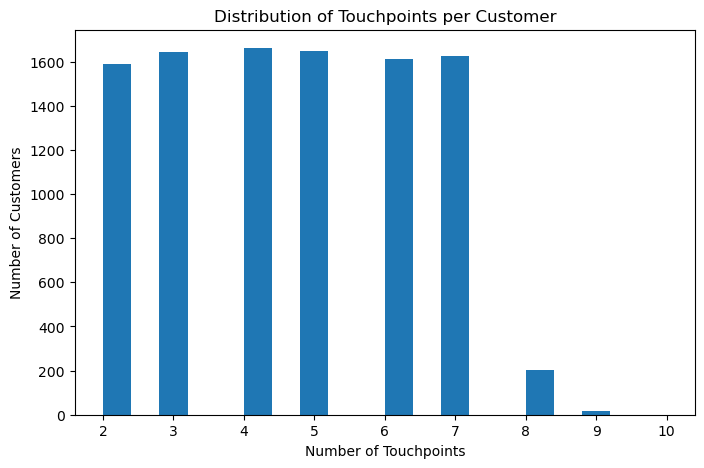

In [32]:
plt.figure(figsize=(8,5))

plt.hist(touchpoints_per_customer, bins=20)

plt.title("Distribution of Touchpoints per Customer")

plt.xlabel("Number of Touchpoints")

plt.ylabel("Number of Customers")

plt.show()

Average Journey Length

In [33]:
print("Average Touchpoints:",
      touchpoints_per_customer.mean())

Average Touchpoints: 4.5815


Conversion Analysis

In [ ]:
#Total Conversions
print("Total Conversions:")
print(Clean_Conversion['user_id'].nunique())

Total Conversions:
1564


In [38]:
#Total Revenue
print("Total Revenue")
print(Clean_Conversion['revenue'].sum())

Total Revenue
1002594.36


Revenue Distribution

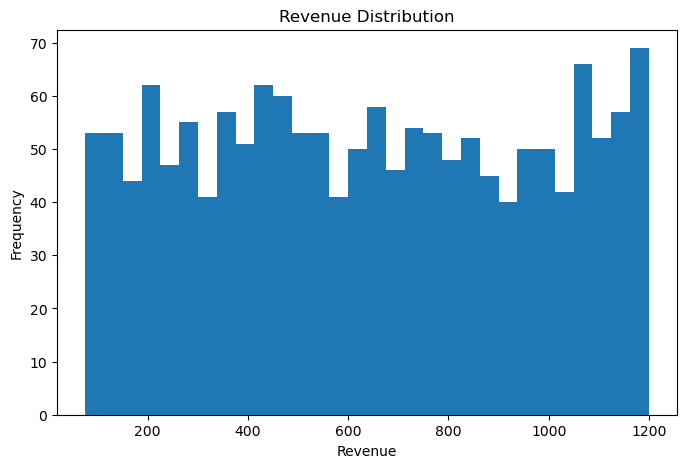

In [39]:
plt.figure(figsize=(8,5))

plt.hist(Clean_Conversion['revenue'], bins=30)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

In [ ]:
#Revenue Summary
Clean_Conversion['revenue'].describe()

count    1564.000000
mean      641.044987
std       329.734181
min        75.770000
25%       363.585000
50%       637.220000
75%       929.212500
max      1199.430000
Name: revenue, dtype: float64

Conversion Behaviour by Channel

In [42]:
conversion_channels = Clean_Weblogs.merge(
    Clean_Conversion[['user_id']],
    on='user_id',
    how='inner'
)

In [43]:
conversion_by_channel = conversion_channels.groupby('channel')['user_id'].nunique()

print(conversion_by_channel)

channel
Facebook Ads    1119
Google Ads      1090
Organic         1094
Tiktok Ads      1092
Name: user_id, dtype: int64


In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values,
    palette="viridis"
)

plt.title("Customer Interactions by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\NNEKA AKANNO\AppData\Local\Temp\ipykernel_4492\3819013802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


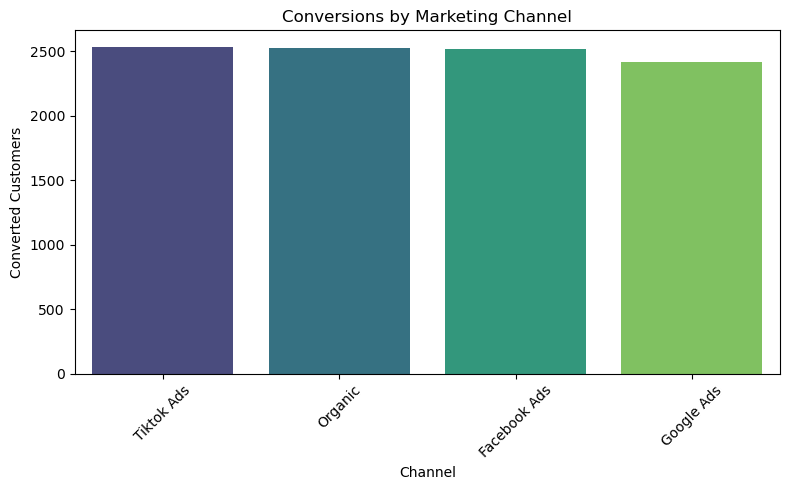

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values,
    palette="viridis"
)

plt.title("Conversions by Marketing Channel")

plt.xlabel("Channel")

plt.ylabel("Converted Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Ad Spend Analysis

In [47]:
#Spend by Channel
channel_spend = Clean_Adspend.groupby('channel')['spend'].sum()
print(channel_spend)

channel
Facebook Ads    517986.43
Google Ads      507942.92
Organic              0.00
Tiktok Ads      484730.82
Name: spend, dtype: float64


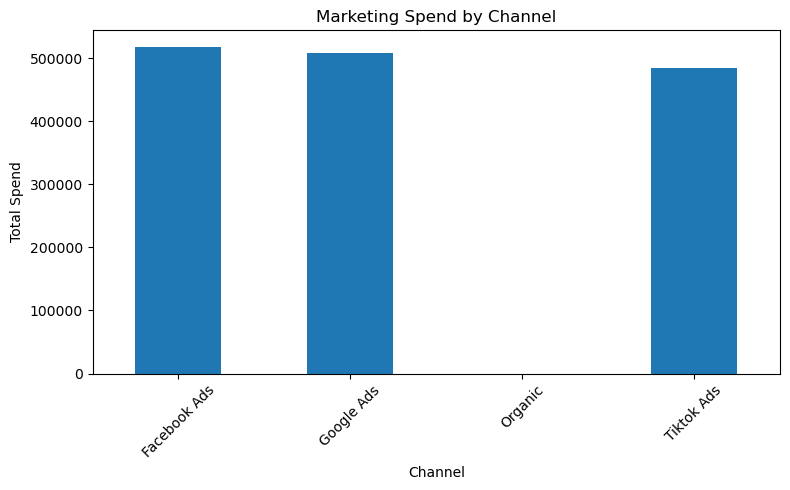

In [48]:
#Spend Allocation Chart
plt.figure(figsize=(8,5))

channel_spend.plot(kind='bar')

plt.title("Marketing Spend by Channel")

plt.xlabel("Channel")

plt.ylabel("Total Spend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [49]:
#Spend by Campaign
campaign_spend = Clean_Adspend.groupby('campaign')['spend'].sum()

campaign_spend.sort_values(ascending=False).head(10)

campaign
Winter Sale           192858.21
Brand Search          185267.47
UGC Campaign          172644.43
Retargeting           170514.64
Competitor Search     164471.28
Influencer Push       161883.35
Generic Search        158204.17
Lookalike Audience    154613.58
Awareness Blast       150203.04
Organic Landing            0.00
Name: spend, dtype: float64

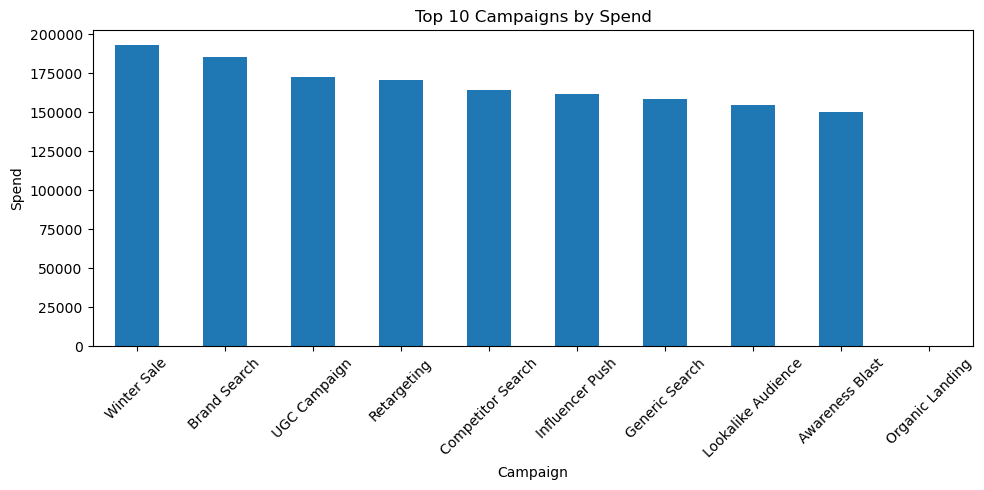

In [50]:
#Campaign Spend Chart
plt.figure(figsize=(10,5))

campaign_spend.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top 10 Campaigns by Spend")

plt.xlabel("Campaign")

plt.ylabel("Spend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Time-Based Analysis

In [51]:
Clean_Weblogs['day_of_week'] = (
    Clean_Weblogs['timestamp']
    .dt.day_name()
)

day_activity = (
    Clean_Weblogs.groupby('day_of_week')
    .size()
)

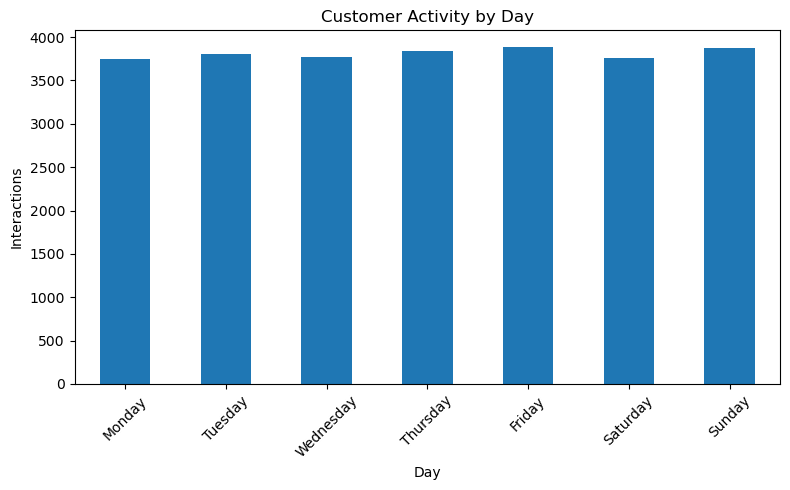

In [52]:
order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_activity = day_activity.reindex(order)

plt.figure(figsize=(8,5))

day_activity.plot(kind='bar')

plt.title("Customer Activity by Day")

plt.xlabel("Day")

plt.ylabel("Interactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Time of Day

In [53]:
Clean_Weblogs['hour'] = (
    Clean_Weblogs['timestamp']
    .dt.hour
)

hourly_activity = (
    Clean_Weblogs.groupby('hour')
    .size()
)

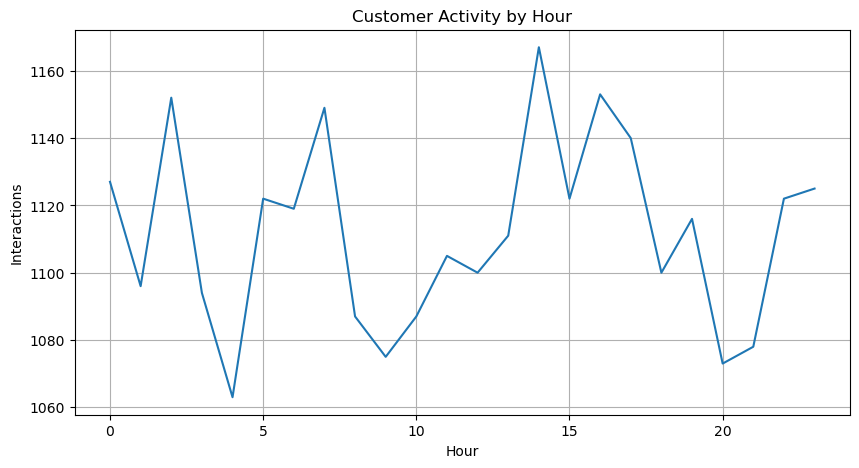

In [54]:
plt.figure(figsize=(10,5))

hourly_activity.plot()

plt.title("Customer Activity by Hour")

plt.xlabel("Hour")

plt.ylabel("Interactions")

plt.grid()

plt.show()

In [55]:
#Daily Activity Trend
Clean_Weblogs['date'] = (
    Clean_Weblogs['timestamp']
    .dt.date
)
daily_activity = (
    Clean_Weblogs.groupby('date')
    .size()
)

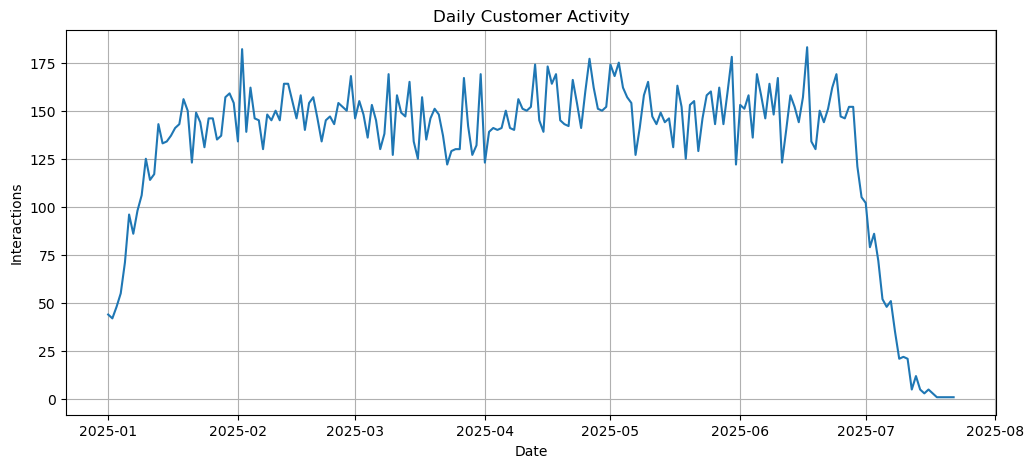

In [56]:
plt.figure(figsize=(12,5))

daily_activity.plot()

plt.title("Daily Customer Activity")

plt.xlabel("Date")

plt.ylabel("Interactions")

plt.grid()

plt.show()

Conversion Rate Visualization

In [57]:
total_users = Clean_Weblogs['user_id'].nunique()

converted_users = Clean_Conversion['user_id'].nunique()

conversion_rate = (
    converted_users /
    total_users
) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 15.64%


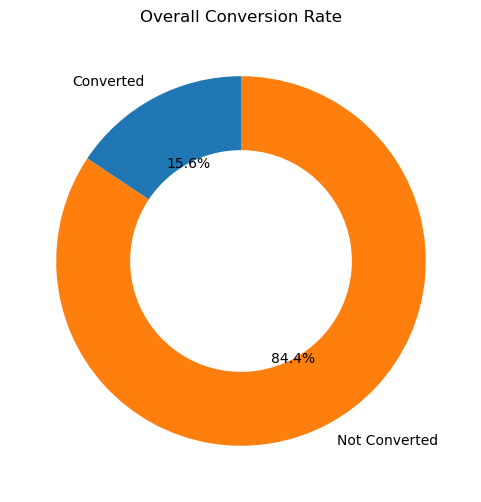

In [61]:
import matplotlib.pyplot as plt

remaining = 100 - conversion_rate

plt.figure(figsize=(6,6))

plt.pie(
    [conversion_rate, remaining],
    labels=['Converted', 'Not Converted'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title('Overall Conversion Rate')

plt.show()